# CNN+LSTM Model - Dataset f17
## 5-Class Speech Emotion Recognition

**Classes:** angry, disgust, fear, sad, neutral

**Dataset:** data_features_f17.csv

**Architecture:** CNN layers + Bidirectional LSTM + Dense layers

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import (Input, Dense, Conv1D, MaxPooling1D, LSTM, 
                                   Dropout, BatchNormalization, Flatten, 
                                   GlobalMaxPooling1D, Bidirectional)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

/Users/giangmytien/Desktop/KLTN/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Libraries imported successfully!


In [2]:
# Load and explore dataset f17
dataset_path = '../dataset step 2/data_features_f17.csv'
data = pd.read_csv(dataset_path)

print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nLabel distribution:")
print(data['label'].value_counts())
print(f"\nFirst few rows:")
data.head()

Dataset shape: (16120, 54)

Columns: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', 'label']

Label distribution:
label
sad        3260
angry      3260
fear       3260
disgust    3260
neutral    3080
Name: count, dtype: int64

First few rows:


,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,label
0,-694.231506,50.040554,0.552267,14.545629,3.444762,-2.469327,-3.988867,-10.599405,-7.204890,1.954130,...,15.456284,17.165444,50.128695,-0.059408,0.028480,-0.040293,-0.083524,0.022426,0.008330,neutral
1,-497.280017,28.192829,3.841719,8.487372,1.427110,-2.888979,-5.544574,-9.694992,-7.155465,-0.981171,...,14.903838,14.855058,13.716436,-0.016542,0.008938,-0.035166,0.021978,-0.000997,0.006767,neutral
2,-693.597229,49.912880,0.489638,14.508638,3.442757,-2.485376,-3.975491,-10.595217,-7.221046,1.962320,...,15.621212,17.211050,49.943609,-0.048962,0.023896,-0.044088,-0.080747,0.020864,0.009322,neutral
3,-706.712158,47.825089,-0.674069,14.761738,2.468847,-4.197237,-6.947045,-11.992122,-5.492224,1.690096,...,16.395725,18.359937,52.078021,0.007574,-0.009324,0.062901,-0.081129,0.011394,-0.002731,neutral
4,-706.450291,51.669993,-0.672582,11.109251,0.728495,-3.095116,-7.086010,-14.615463,-9.870567,2.474204,...,17.017283,19.283632,48.501982,-0.024749,0.009397,-0.086847,0.040578,-0.017416,-0.000269,neutral


In [3]:
# Data preprocessing
# Filter for 5 classes only
target_classes = ['angry', 'disgust', 'fear', 'sad', 'neutral']
data_filtered = data[data['label'].isin(target_classes)].copy()

print(f"Filtered dataset shape: {data_filtered.shape}")
print(f"\nClass distribution after filtering:")
label_counts = data_filtered['label'].value_counts()
for label, count in label_counts.items():
    percentage = (count / len(data_filtered)) * 100
    print(f"   {label}: {count} samples ({percentage:.1f}%)")

# Prepare features and labels
X = data_filtered.drop('label', axis=1).values
y = data_filtered['label'].values

print(f"\nFeatures shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of classes: {len(label_encoder.classes_)}")

Filtered dataset shape: (16120, 54)

Class distribution after filtering:
   sad: 3260 samples (20.2%)
   angry: 3260 samples (20.2%)
   fear: 3260 samples (20.2%)
   disgust: 3260 samples (20.2%)
   neutral: 3080 samples (19.1%)

Features shape: (16120, 53)
Number of features: 53
Classes: ['angry' 'disgust' 'fear' 'neutral' 'sad']
Number of classes: 5


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for CNN+LSTM input (samples, timesteps, features)
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Reshaped train data: {X_train_reshaped.shape}")
print(f"Reshaped test data: {X_test_reshaped.shape}")

# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

print(f"Categorical labels shape: {y_train_cat.shape}")

Train samples: 12896
Test samples: 3224
Reshaped train data: (12896, 53, 1)
Reshaped test data: (3224, 53, 1)
Categorical labels shape: (12896, 5)


In [5]:
# Create CNN+LSTM model
def create_cnn_lstm_model(input_shape, num_classes=5):
    """
    Create CNN+LSTM model for speech emotion recognition
    
    Architecture:
    1. Convolutional layers for local feature extraction
    2. LSTM layers for temporal modeling
    3. Dense layers for classification
    """
    
    inputs = Input(shape=input_shape, name='input')
    
    # CNN Block 1
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same', name='conv1d_1')(inputs)
    x = BatchNormalization(name='bn_1')(x)
    x = MaxPooling1D(pool_size=2, name='maxpool_1')(x)
    x = Dropout(0.25, name='dropout_1')(x)
    
    # CNN Block 2
    x = Conv1D(128, kernel_size=3, activation='relu', padding='same', name='conv1d_2')(x)
    x = BatchNormalization(name='bn_2')(x)
    x = MaxPooling1D(pool_size=2, name='maxpool_2')(x)
    x = Dropout(0.25, name='dropout_2')(x)
    
    # CNN Block 3
    x = Conv1D(256, kernel_size=3, activation='relu', padding='same', name='conv1d_3')(x)
    x = BatchNormalization(name='bn_3')(x)
    x = Dropout(0.25, name='dropout_3')(x)
    
    # LSTM Blocks
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3), name='bilstm_1')(x)
    x = Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3), name='bilstm_2')(x)
    
    # Dense layers
    x = Dense(256, activation='relu', name='dense_1')(x)
    x = BatchNormalization(name='bn_final')(x)
    x = Dropout(0.5, name='dropout_final')(x)
    
    x = Dense(128, activation='relu', name='dense_2')(x)
    x = Dropout(0.3, name='dropout_dense')(x)
    
    # Output layer
    outputs = Dense(num_classes, activation='softmax', name='output')(x)
    
    model = Model(inputs, outputs, name='CNN_LSTM_EmotionRecognition')
    return model

# Build model
input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2])
model = create_cnn_lstm_model(input_shape)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN+LSTM model created and compiled!")
model.summary()

CNN+LSTM model created and compiled!


Model: "CNN_LSTM_EmotionRecognition"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 53, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 53, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 53, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling1D)        │ (None, 26, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 26, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 26, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 26, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling1D)        │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 13, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 13, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 13, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_final (BatchNormalization)   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_final (Dropout)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 751,493 (2.87 MB)

 Trainable params: 750,085 (2.86 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [6]:
# Training
print("Starting training...")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

#model_checkpoint = ModelCheckpoint(
#    'best_cnn_lstm_f01.h5',
#    monitor='val_accuracy',
#    save_best_only=True,
#    verbose=1
#)

# Train model
history = model.fit(
    X_train_reshaped, y_train_cat,
    validation_data=(X_test_reshaped, y_test_cat),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("Training completed!")

Starting training...
Epoch 1/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 112s 219ms/step - accuracy: 0.4453 - loss: 1.5155 - val_accuracy: 0.5574 - val_loss: 1.0738 - learning_rate: 0.0010
Epoch 2/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 106s 263ms/step - accuracy: 0.7057 - loss: 0.7689 - val_accuracy: 0.7823 - val_loss: 0.5232 - learning_rate: 0.0010
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 107s 265ms/step - accuracy: 0.7452 - loss: 0.6321 - val_accuracy: 0.8105 - val_loss: 0.4632 - learning_rate: 0.0010
Epoch 4/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 97s 241ms/step - accuracy: 0.7804 - loss: 0.5640 - val_accuracy: 0.8310 - val_loss: 0.4173 - learning_rate: 0.0010
Epoch 5/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 102s 252ms/step - accuracy: 0.8040 - loss: 0.5120 - val_accuracy: 0.8415 - val_loss: 0.4075 - learning_rate: 0.0010
Epoch 6/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 97s 242ms/step - accuracy: 0.8102 - loss: 0.4822 - val_accuracy: 0.8400 - val_loss: 0.3972 - learning_rate: 0.0010
Epoch 7/100
403/403 ━━━━━━━━━━━━━━━━━━━

In [7]:
# Evaluation and Results
print("CNN+LSTM MODEL EVALUATION - Dataset f17")
print("=" * 60)

# Predictions
y_pred_prob = model.predict(X_test_reshaped, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Test accuracy
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Classification Report
print(f"\nCLASSIFICATION REPORT:")
print("-" * 50)
class_names = label_encoder.classes_
report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report)

# Cohen's Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f"\nCohen's Kappa Score: {kappa:.4f}")

# Training Summary
epochs_trained = len(history.history['accuracy'])
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\nTRAINING SUMMARY:")
print("-" * 50)
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Epochs Trained: {epochs_trained}")

CNN+LSTM MODEL EVALUATION - Dataset f17
Test Accuracy: 0.9650
Test Loss: 0.1195

CLASSIFICATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

       angry     0.9755    0.9755    0.9755       652
     disgust     0.9621    0.9724    0.9672       652
        fear     0.9811    0.9571    0.9689       652
     neutral     0.9580    0.9627    0.9603       616
         sad     0.9483    0.9571    0.9527       652

    accuracy                         0.9650      3224
   macro avg     0.9650    0.9649    0.9649      3224
weighted avg     0.9651    0.9650    0.9650      3224


Cohen's Kappa Score: 0.9562

TRAINING SUMMARY:
--------------------------------------------------
Final Training Accuracy: 0.9783
Final Validation Accuracy: 0.9612
Final Training Loss: 0.0594
Final Validation Loss: 0.1185
Epochs Trained: 100



CONFUSION MATRIX:
--------------------------------------------------
Predicted ->
True    angry     disgust   fear      neutral   sad       
angry   636       6         4         3         3         
disgust 6         634       4         6         2         
fear    7         9         624       0         12        
neutral 3         2         1         593       17        
sad     0         8         3         17        624       


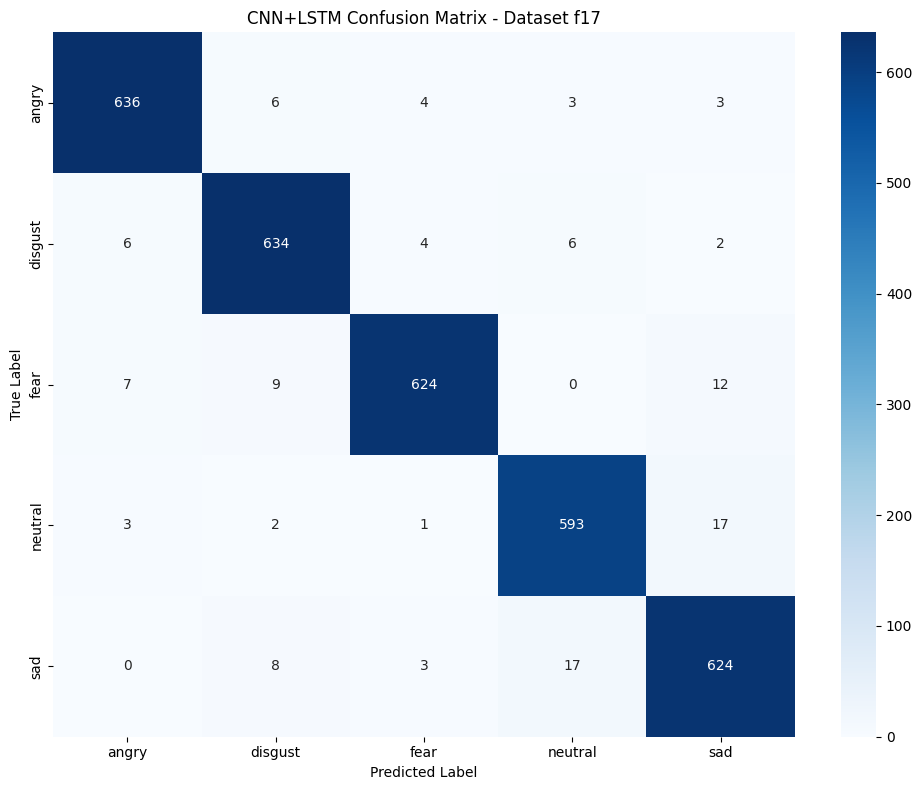

In [8]:
# Confusion Matrix
print(f"\nCONFUSION MATRIX:")
print("-" * 50)
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix in text format
print("Predicted ->")
print(f"{'True':<8}", end="")
for class_name in class_names:
    print(f"{class_name:<10}", end="")
print()

for i, class_name in enumerate(class_names):
    print(f"{class_name:<8}", end="")
    for j in range(len(class_names)):
        print(f"{cm[i,j]:<10}", end="")
    print()

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('CNN+LSTM Confusion Matrix - Dataset f17')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

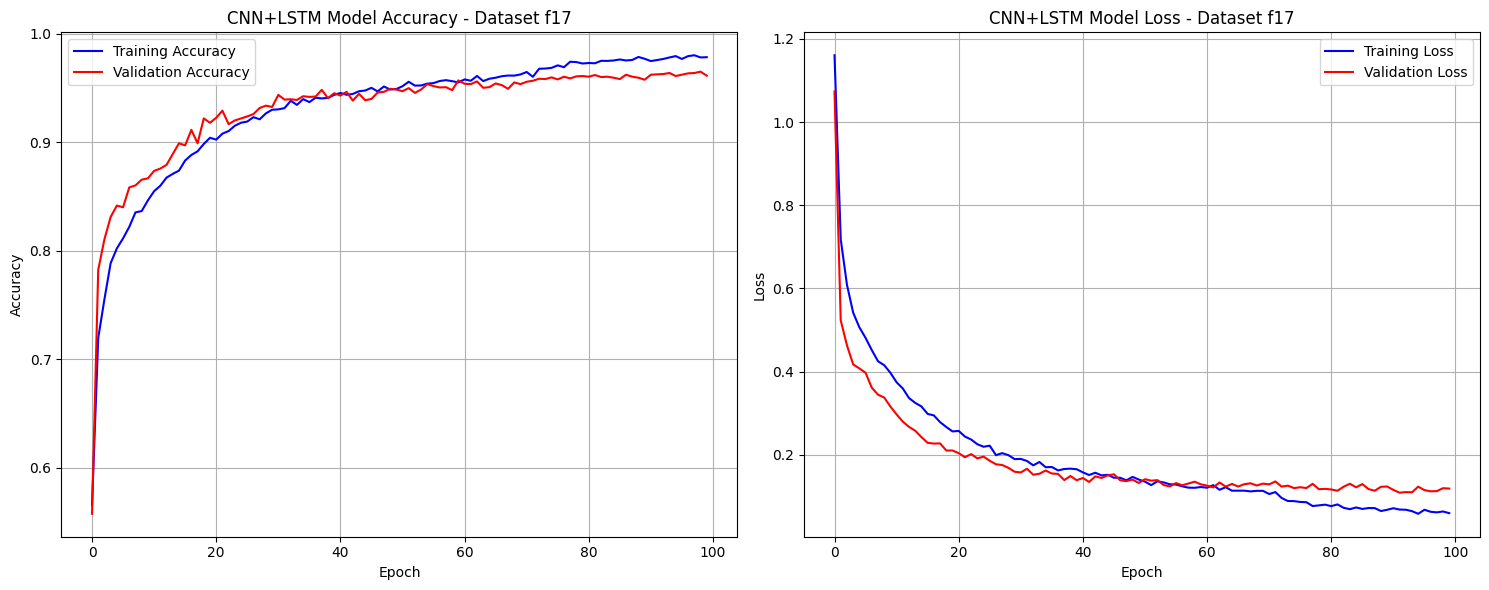

Training history plots generated!


In [9]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax1.set_title('CNN+LSTM Model Accuracy - Dataset f17')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red')
ax2.set_title('CNN+LSTM Model Loss - Dataset f17')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Training history plots generated!")

In [10]:
# Final summary
print(f"\nFINAL RESULTS SUMMARY - CNN+LSTM f17")
print("=" * 60)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Epochs Trained: {epochs_trained}")
print(f"Dataset: data_features_f17.csv")
print(f"Classes: {', '.join(class_names)}")


FINAL RESULTS SUMMARY - CNN+LSTM f17
Test Accuracy: 0.9650
Cohen's Kappa: 0.9562
Epochs Trained: 100
Dataset: data_features_f17.csv
Classes: angry, disgust, fear, neutral, sad
